# Notas de aula: Mecânica Quântica, Autor: Jonas Maziero, Departamento de Física, UFSM
Links para os vídeos das aulas sobre esse tópico: https://youtu.be/rbPs2vogO0E e .

In [1]:
%run init.ipynb

# Problema de dois estados, na representação de interação
Consideremos o Hamiltoniano dependente do tempo
\begin{equation}
H_{t}=H_{c}+V_{t},
\end{equation}
onde
\begin{equation}
H_{c} = E_{1}^{c} |E_{1}^{c}\rangle\langle E_{1}^{c}| + E_{2}^{c} |E_{2}^{c}\rangle\langle E_{2}^{c}| =: e_{1} |1\rangle\langle 1| + e_{2} |2\rangle\langle 2| = \begin{bmatrix} e_{1} & 0 \\ 0 & e_{2} \end{bmatrix},
\end{equation}
é a parte independente do tempo do Hamiltoniano (ou, para sistemas compostos, a parte que descreve quantons individuais) e
\begin{equation}
V_{t} = \gamma\left(e^{i\omega t} |1\rangle\langle 2| + e^{-i\omega t} |2\rangle\langle 1| \right) = \begin{bmatrix} 0 & \gamma e^{i\omega t} \\ \gamma e^{-i\omega t} & 0 \end{bmatrix},
\end{equation}
é a parte dependente do tempo do Hamiltoniano, geralmente de interação com uma campo clássico dependente do tempo (ou, para sistemas compostos, a parte de interação entre quantons).
Acima $e_{2}>e_{1}$ e as representações são feitas na base padrão $\{|j\rangle\}_{j=1}^{2}$. 

Note que $\gamma$ dita a intensidade da interação e a frequência de algumas mudanças temporais que ocorrerão neste sistema. Vale observar também que
\begin{equation}
H_{t} = \begin{bmatrix} e_{1} & \gamma e^{i\omega t} \\ \gamma e^{-i\omega t} & e_{2} \end{bmatrix}
\end{equation}
é a matriz 2x2 Hermitiana mais geral que podemos construir. Em relação ao tempo, o que poderíamos fazer de mais geral é usar $e_{j}(t)$, $\gamma(t)$ e $\omega(t)$.

_OBS:_ Verifiquemos que esse Hamiltoniano não comuta em tempos diferentes, e por conseguinte não poderemos utilizar $U_{t} = e^{-\frac{i}{\hbar}\int_{0}^{t}H(t')dt'}$. E esse é um exemplo de situação onde é útil usar a representação de interação.

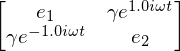

In [10]:
w, e1, e2, t, t1, t2, g = symbols('omega e_{1} e_{2} t t_{1} t_{2} gamma')
def H(t):
    return Matrix([[e1,g*exp(1j*w*t)],[g*exp(-1j*w*t),e2]])
H(t)

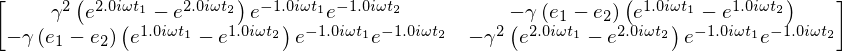

In [13]:
factor(comm(H(t1),H(t2)))

Vemos assim que $[H_{t},H_{t'}]=\mathbb{0}$ se e somente se $t=t'$.

Lembrando, na RI escrevemos
\begin{equation}
|\psi_{t}^{I}\rangle = \sum_{j=1}^{2} c_{j}(t)|{j}\rangle=c_{1}(t)|{1}\rangle+c_{2}(t)|{2}\rangle
\end{equation}
e chegamos na eq. matricial para os coeficientes
\begin{align}
i\hbar\begin{bmatrix}\partial_{t}c_{1} \\ \partial_{t}c_{2}\end{bmatrix} & = \begin{bmatrix} V_{11} & V_{12}e^{i\omega_{12}t} \\ V_{21}e^{i\omega_{21}t} & V_{22} \\ \end{bmatrix}\begin{bmatrix}c_{1} \\ c_{2}\end{bmatrix}  = \begin{bmatrix} 0 & \gamma e^{i\omega t}e^{-i\omega_{21}t} \\ \gamma e^{-i\omega t}e^{i\omega_{21}t} & 0 \\ \end{bmatrix}\begin{bmatrix}c_{1} \\ c_{2}\end{bmatrix} \\
& = \begin{bmatrix}\gamma e^{i(\omega-\omega_{21}) t}c_{2} \\ \gamma e^{-i(\omega-\omega_{21}) t}c_{1}\end{bmatrix}
,
\end{align}
onde para o presente Hamiltoniano usamos que $\omega_{21} = -\omega_{12} = (e_{2}-e_{1})/\hbar$ e $V_{11} = V_{22} = 0$ e $V_{12} = V_{21}^{*} = \gamma e^{i\omega t}$.

Para desacoplar esse sistema de equações lineares, vamos tomar a derivada temporal dessas eqs.:
\begin{cases}
i\hbar\partial_{tt}c_{1} = i\gamma(\omega-\omega_{21})e^{i(\omega-\omega_{21})t}c_{2} + \gamma e^{i(\omega-\omega_{21})t}\frac{i\hbar}{i\hbar}\partial_{t}c_{2}, \\
i\hbar\partial_{tt}c_{2} = -i\gamma(\omega-\omega_{21})e^{-i(\omega-\omega_{21})t}c_{1} + \gamma e^{-i(\omega-\omega_{21})t}\frac{i\hbar}{i\hbar}\partial_{t}c_{1}.
\end{cases}
Usando as eqs. diferenciais de primeira ordem obteremos:
\begin{cases}
i\hbar\partial_{tt}c_{1} = i(\omega-\omega_{21})i\hbar\partial_{t}c_{1} + \gamma e^{i(\omega-\omega_{21})t}\frac{1}{i\hbar}\gamma e^{-i(\omega-\omega_{21}) t}c_{1}, \\
i\hbar\partial_{tt}c_{2} = -i(\omega-\omega_{21})i\hbar\partial_{t}c_{2} + \gamma e^{-i(\omega-\omega_{21})t}\frac{1}{i\hbar}\gamma e^{i(\omega-\omega_{21}) t}c_{2}.
\end{cases}
Rearranjamos essas eqs. para obter o seguinte conjunto de _eqs. diferenciais de segunda ordem mas desacopladas_:
\begin{cases}
\partial_{tt}c_{1} - i(\omega-\omega_{21})\partial_{t}c_{1} + \frac{\gamma^{2}}{\hbar^{2}}c_{1} = 0, \\
\partial_{tt}c_{2} + i(\omega-\omega_{21})\partial_{t}c_{2} + \frac{\gamma^{2}}{\hbar^{2}}c_{2} = 0.
\end{cases}
Abaixo vamos fazer uso do sympy para obter a _solução_ desse sistema.

#### Solução de equações diferenciais do tipo
\begin{equation}
\partial_{tt}y+b\partial_{t}y+cy=0
\end{equation} 
para $y=y(t)$. Se acharmos duas soluções particulares $y_{1}$ e $y_{2}$ linearmente independentes, podemos construir uma solução geral $y=c_{1}y_{1}+c_{2}y_{2}$ com $c_{1},c_{2}\in\mathbb{C}$. Testamos uma solução do tipo
\begin{equation}
y = e^{rt} \therefore \partial_{t}y=re^{rt}=ry \therefore \partial_{tt}y=r^{2}e^{rt}=r^{2}y.
\end{equation}
Substituindo na eq. diferencial
\begin{equation}
r^{2}y+bry+cy=(r^{2}+br+c)y=0\therefore r = \frac{-b\pm\sqrt{b^{2}-4c}}{2} =: r_{\pm}.
\end{equation}
Temos com isso que $e^{r_{+}t}$ e $e^{r_{-}t}$ são soluções da eq. diferencial acima. Se $r_{+}\ne r_{-}$ podemos construir uma solução geral como
\begin{equation}
y(t) = C_{1}e^{r_{+}t}+C_{2}e^{r_{-}t} = e^{-bt/2}\left(C_{1}e^{\sqrt{b^{2}-4c}t/2}+C_{2}e^{-\sqrt{b^{2}-4c}t/2}\right).
\end{equation}

OBS. Nos casos em que $r_{+}=r_{-}$ a solução geral é escrita como
\begin{equation}
y(t) = C_{1}e^{r_{+}t}+C_{2}te^{r_{-}t} = e^{-bt/2}\left(C_{1}e^{\sqrt{b^{2}-4c}t/2}+C_{2}te^{-\sqrt{b^{2}-4c}t/2}\right).
\end{equation}

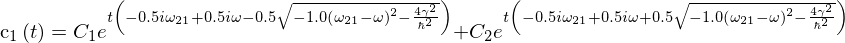

In [4]:
w21, hb = symbols('\omega_{21} \hbar')
c1 = Function('c1')
dsolve(Derivative(c1(t),t,t) - 1j*(w-w21)*Derivative(c1(t),t) + (g**2/hb**2)*c1(t), c1(t))

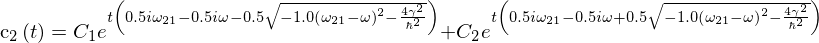

In [5]:
c2 = Function('c2')
dsolve(diff(c2(t),t,t) + 1j*(w-w21)*diff(c2(t),t) + (g**2/hb**2)*c2(t), c2(t))

Para a eq. diferencial para $c_{1}$, temos $b=-i(\omega-\omega_{21})$ e $c=\gamma^{2}/\hbar^{2}$. Assim
\begin{align}
c_{1}(t) & = e^{i(\omega-\omega_{21})t/2}\left(C_{1}e^{\sqrt{-(\omega-\omega_{21})^{2}-4\gamma^{2}/\hbar^{2}}t/2}+C_{2}e^{-\sqrt{-(\omega-\omega_{21})^{2}-4\gamma^{2}/\hbar^{2}}t/2}\right) \\
& = e^{i(\omega-\omega_{21})t/2}\left(C_{1}e^{i\sqrt{((\omega-\omega_{21})/2)^{2}+\gamma^{2}/\hbar^{2}}t}+C_{2}e^{-i\sqrt{((\omega-\omega_{21})/2)^{2}+\gamma^{2}/\hbar^{2}}t}\right).
\end{align}
Da eq. diferencial para $c_{2}$, temos $b=i(\omega-\omega_{21})$ e $c=\gamma^{2}/\hbar^{2}$. Então
\begin{equation}
c_{2}(t) = e^{-i(\omega-\omega_{21})t/2}\left(C'_{1}e^{i\sqrt{((\omega-\omega_{21})/2)^{2}+\gamma^{2}/\hbar^{2}}t}+C'_{2}e^{-i\sqrt{((\omega-\omega_{21})/2)^{2}+\gamma^{2}/\hbar^{2}}t}\right)
\end{equation}

Definindo
\begin{equation}
\xi := \sqrt{\frac{\gamma^{2}}{\hbar^{2}}+\left(\frac{\omega-\omega_{21}}{2}\right)^{2}}. 
\end{equation}
reescrevemos as soluções acima como
\begin{align}
c_{1}(t) & = e^{i(\omega-\omega_{21})t/2}\left(C_{1} e^{-i\xi t} + C_{2}e^{i\xi t}\right), \\
         & = e^{i(\omega-\omega_{21})t/2}\left[(C_{1}+C_{2})\cos\xi t + i(C_{2}-C_{1})\sin\xi t\right], \\
         & =: e^{i(\omega-\omega_{21})t/2}\left(k_{1}\sin\xi t + k_{2}\cos\xi t \right), \\
c_{2}(t) & =\cdots= e^{-i(\omega-\omega_{21})t/2}\left(k_{3}\sin\xi t + k_{4}\cos\xi t \right),
\end{align}
As constantes $\{k_{j}\}_{j=1}^{4}$ deve ser determinadas pelas condições iniciais e de normalização.

__Especificando o estado inicial__ <br>
Vamos começar assumindo que o sistema está _inicialmente_ no estado fundamental do Hamiltoniano independente do tempo $H_{c}$, i.e.,
\begin{equation}
|\psi_{0}^{I}\rangle = |\psi^{s}\rangle = |1\rangle.
\end{equation}
Nesse caso, devemos ter
\begin{align}
c_{1}(0) & = e^{0}\left(k_{1}\sin(0) + k_{2}\cos(0)\right) = k_{2} = 1, \\
c_{2}(0) & = e^{0}\left(k_{3}\sin(0) + k_{4}\cos(0)\right) = k_{4} = 0.
\end{align}
Vem assim que
\begin{equation}
c_{2}(t) = e^{-i(\omega-\omega_{21})t/2}k_{3}\sin\xi t.
\end{equation}
Para facilitar a solução desse problema, usamos uma das equações do sistema original, $i\hbar\partial_{t}c_{2}(t)= \gamma e^{-i(\omega-\omega_{21}) t}c_{1}(t)$, para escrever
\begin{align}
c_{1}(t) & = \gamma^{-1}e^{i(\omega-\omega_{21}) t}i\hbar\partial_{t}c_{2}(t) \\
         & = \gamma^{-1}e^{i(\omega-\omega_{21}) t}i\hbar\left(-i\frac{\omega-\omega_{21}}{2}e^{-i(\omega-\omega_{21})t/2}k_{3}\sin\xi t  + \xi e^{-i(\omega-\omega_{21})t/2}k_{3}\cos\xi t\right) \\
         & = \gamma^{-1}i\hbar k_{3}e^{i(\omega-\omega_{21}) t/2}\left(-i\frac{\omega-\omega_{21}}{2}\sin\xi t  + \xi\cos\xi t\right).
\end{align}

Agora aplicamos a normalização do estado $|\psi_{t}^{I}\rangle=c_{1}|1\rangle+c_{2}|2\rangle$:
\begin{align}
& |c_{1}(t)|^{2} + |c_{2}(t)|^{2} = 1 \\
& \gamma^{-2}\hbar^{2} k_{3}^{2}\left(-i\frac{\omega-\omega_{21}}{2}\sin\xi t  + \xi\cos\xi t\right)\left(i\frac{\omega-\omega_{21}}{2}\sin\xi t  + \xi\cos\xi t\right) + k_{3}^{2}\sin^{2}\xi t = 1 \\
& \gamma^{-2}\hbar^{2} k_{3}^{2}\left(\left(\frac{\omega-\omega_{21}}{2}\right)^{2}\sin^{2}\xi t  + \xi^{2}\cos^{2}\xi t\right) + k_{3}^{2}\sin^{2}\xi t = 1 \\ 
& k_{3}^{2}\left(\left(\left(\frac{\omega-\omega_{21}}{2}\right)^{2}\sin^{2}\xi t  + \xi^{2}\cos^{2}\xi t\right) + (\gamma^{2}/\hbar^{2})\sin^{2}\xi t \right)= \gamma^{2}/\hbar^{2}.
\end{align}

Assim
\begin{align}
k_{3}^{2} & = \frac{\gamma^{2}/\hbar^{2}}{\left(\left(\frac{\omega-\omega_{21}}{2}\right)^{2}+\frac{\gamma^{2}}{\hbar^{2}}\right)\sin^{2}\xi t  + \xi^{2}\cos^{2}\xi t} = \frac{\gamma^{2}/\hbar^{2}}{\xi^{2}\sin^{2}\xi t  + \xi^{2}\cos^{2}\xi t} = \frac{\gamma^{2}/\hbar^{2}}{\gamma^{2}/\hbar^{2} + \left(\frac{\omega-\omega_{21}}{2}\right)^{2}} \\
& = \frac{1}{1 + \left(\frac{\hbar\omega_{21}}{2\gamma}\left(1-\frac{\omega}{\omega_{21}}\right)\right)^{2}}.
\end{align}

A probabilidade de transição $|1\rangle\rightarrow|2\rangle$, que é igual a probabilidade de, em uma medida de energia no instante de tempo $t$, obtermos $e_{2}$ é:
\begin{equation}
Pr(2(t)) = \left|\langle 2|\psi_{t}^{I}\rangle\right|^{2} = \left|c_{2}(t)\right|^{2} = k_{3}^{2}\sin^{2}\xi t = \frac{\sin^{2}\xi t}{1 + \left(\frac{\hbar\omega_{21}}{2\gamma}\left(1-\frac{\omega}{\omega_{21}}\right)\right)^{2}},
\end{equation}
primeiramente notamos que as _probabilidades oscilam sinudoisalmente_ com o tempo, com amplitude máxima determinada por $k_{3}$. 

In [67]:
def pr2t(g,w):
    hbb = 1; w21 = 1
    t = np.arange(0,10,0.05); k32 = 1/(1+(((hbb*w21)/(2*g))*(1-w/w21))**2)
    csi = math.sqrt((g/hbb)**2+((w-w21)/2)**2); pr2 = k32*(np.sin(csi*t)**2)
    plt.plot(t, pr2); plt.xlabel(r'$t$'); plt.ylabel(r'$Pr(2(t))$')
    plt.annotate(r'$\gamma=$'+str(g)[:4], xy=(8,0.9), xytext=(8,0.9), fontsize=13)
    plt.annotate(r'$\omega=$'+str(w)[:4], xy=(8,0.8), xytext=(8,0.8), fontsize=13)
    plt.xlim([0,10]); plt.ylim([0,1]); plt.show()
interactive(pr2t, g = (0.01,3,0.1), w = (0,5,0.1))

interactive(children=(FloatSlider(value=1.4100000000000001, description='g', max=3.0, min=0.01), FloatSlider(v…

Ademais, só teremos probabilidade máxima de encontrar o sistema no estado excitado se $\omega=\omega_{21}$ (que resulta em $k_{3}=1$), que é a condição de _ressonância_. Ou seja, o termo dependente do tempo do Hamiltoniano terá eficiência máxima em causar transição entre os níveis de energia quando sua frequência for igual à frequência de Bohr do sistema, ou seja, quando estivermos na chamada condição de ressonância. 

A dependência da probabilidade máxima
\begin{equation}
\max_{t}Pr(2(t)) = k_{3}^{2}
\end{equation}
com a razão entre as escalas de intensidade das interações de $H_{c}$ e de $V_{t}$, i.e., $\hbar\omega_{21}/\gamma$ e entre as frequências "aplicada" e natural do sistema pode ser estudada com os gráficos produzidos com o código abaixo. Os tempos para os quais a probabilidade é máxima são:
\begin{equation}
\xi t_{\max}=(2j+1)\frac{\pi}{2} \therefore t_{\max} = \frac{(2j+1)\pi}{2\xi} \text{ com } j=0,1,2,3,\cdots.
\end{equation}

In [71]:
def pr2m(g):
    hbb = 1; w21 = 20
    w = np.arange(0,40,0.01); k32 = 1/(1+(((hbb*w21)/(2*g))*(1-w/w21))**2)
    plt.plot(w, k32); plt.xlabel(r'$\omega/\omega_{21}$'); plt.ylabel(r'$Pr(2(t))_{\max}$')
    plt.annotate(r'$\gamma=$'+str(g)[:4], xy=(30,0.8), xytext=(30,0.8), fontsize=13)
    plt.xlim([0,40]); plt.ylim([0,1.01]); plt.show()
interactive(pr2m, g = (0.01,2,0.05))

interactive(children=(FloatSlider(value=0.9600000000000001, description='g', max=2.0, min=0.01, step=0.05), Ou…

## Ressonância magnética de spin
Consideremos uma partícula de spin 1/2 sujeita ao seguinte campo magnético
\begin{equation}
\vec{B}(t) = B_{0}\hat{k} - B_{1}\left(\hat{i}\cos\omega t - \hat{j}\sin\omega t\right),
\end{equation}
com $B_{0}$ e $B_{1}$ constantes positivas. Note que há um termo constante na direção $z$ e outro termo que gira no plano $xy$. Para esta interação o Hamiltoniano será
\begin{align}
H & = -\vec{\mu}\cdot\vec{B}(t) = -\frac{\hbar gq}{4m}\vec{\sigma}\cdot\vec{B}(t) = -\frac{\hbar gq}{4m}(\sigma_{x}\hat{i}+\sigma_{y}\hat{j}+\sigma_{z}\hat{k})\cdot\left(B_{0}\hat{k} - B_{1}\left(\hat{i}\cos\omega t - \hat{j}\sin\omega t\right)\right) \\
  & = -\frac{\hbar gq B_{0}}{4m}\sigma_{z} + \frac{\hbar gq B_{1}}{4m}(\sigma_{x}\cos\omega t - \sigma_{y}\sin\omega t) = -\frac{\hbar\omega_{21}}{2}\sigma_{z} + \gamma(\sigma_{x}\cos\omega t - \sigma_{y}\sin\omega t) \\
  & = e_{1}|z_{+}\rangle\langle z_{+}| + e_{2}|z_{-}\rangle\langle z_{-}| + \gamma[(|z_{+}\rangle\langle z_{-}|+|z_{-}\rangle\langle z_{+}|)\cos\omega t - (-i|z_{+}\rangle\langle z_{-}|+i|z_{-}\rangle\langle z_{+}|)\sin\omega t)] \\
  & = H_{c} + \gamma[|z_{+}\rangle\langle z_{-}|(\cos\omega t +i\sin\omega t) + |z_{-}\rangle\langle z_{+}|(\cos\omega t -i\sin\omega t)] \\
  & = H_{c} + \gamma(|z_{+}\rangle\langle z_{-}|e^{i\omega t} + |z_{-}\rangle\langle z_{+}|e^{-i\omega t}) \\
  & = H_{c} + V_{t},
\end{align}
onde definimos $\omega_{21} = gqB_{0}/2m$ e $\gamma = \hbar qgB_{1}/4m$.

Como esse Hamiltoniano é idêntico ao que consideramos na última seção, todos os resultados obtidos lá se aplicam aqui. Sabemos que se $B_{1}=0$ o spin precessará em torno da direção $z$. No entando, se $B_{1}>0$ teremos "flips" entre os estados
\begin{equation}
|z_{+}\rangle\leftrightarrow|z_{-}\rangle.
\end{equation}
A freqûencia com que essas transições ocorrerão depende das razões $\gamma/\omega_{21}$ e $\omega/\omega_{21}$, como analizado acima.

A ressonância magnética nuclear (ou qualquer outro tipo de ressonância magnética) consiste de, dentro do contexto dos cálculos que fizemos, aplicar $V_{t}$ por um tempo $\tau$ suficiente para que $c_{1}=c_{2}=1/\sqrt{2}$, e assim preparar o quanton no estado de momentos magnético:
\begin{equation}
\frac{1}{\sqrt{2}}|z_{+}\rangle + \frac{1}{\sqrt{2}}|z_{-}\rangle \equiv |x_{+}\rangle.
\end{equation}
Depois, para um ensemble com muitos spins, mede-se momento magnético médio (através do campo magnético gerado) em alguma diração no plano $xy$. Como $B_{1}(t>\tau)=0$, os spins simplesmente precessariam em torno da direção $z$, 
\begin{align}
\langle\sigma_{x}(t)\rangle = \langle\sigma_{x}\rangle\cos(\omega t) + \langle\sigma_{y}\rangle\sin(\omega t) = \langle\sigma_{x}\rangle\cos(\omega t) + \langle\sigma_{y}\rangle\cos(\omega t-\pi/2),
\end{align}
como mostrado na figura abaixo.

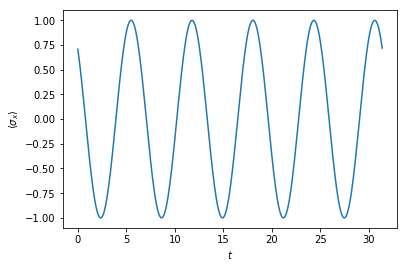

In [54]:
t = np.arange(0,10*math.pi,0.1); w = 1; r1 = 1/math.sqrt(2); r2 = r1
r1t = r1*np.cos(w1*t) - r2*np.sin(w1*t); plt.plot(t,r1t)
plt.xlabel(r'$t$'); plt.ylabel(r'$\langle\sigma_{x}\rangle$')
plt.show()

No entanto, a temperatura é diferente de zero e todo sistema deixado evoluir livremente sob a ação de um banho térmico vai trocar energia com este último e estará, depois de um tempo longo, em um dos auto-estados do Hamiltoniano, $|z_{\pm}\rangle$, com probabilidade $\propto e^{-\beta E_{\pm}}$ com $\beta=1/k_{B}T$, onde $k_{B}$ é a constante de Boltzmann e $T$ é a temperatura do ambiente. Conforme o tempo passa, e mais e mais spins passam para os estados $|z_{\pm}\rangle$, o momento magnético médio diminui. Esse decaimento é exponencial. Exemplificamos esse comportamento,
\begin{align}
\langle\sigma_{x}(t)\rangle = (\langle\sigma_{x}\rangle\cos(\omega t) + \langle\sigma_{y}\rangle\cos(\omega t-\pi/2))e^{-\Gamma_{1}t},
\end{align}
com a figura abaixo.

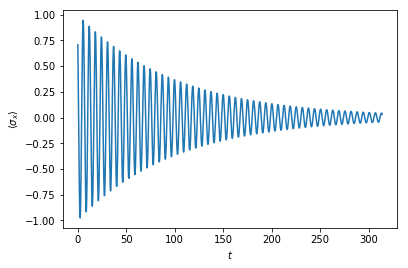

In [68]:
t = np.arange(0,100*math.pi,0.1); T1 = 100; a = (1-np.exp(t/T1))/2
w1 = 1; w2 = 10; r1 = 1/math.sqrt(2); r2 = r1
r1t = (r1*np.cos(w1*t) - r2*np.sin(w1*t))*np.exp(-t/T1) \
#+ (r1*np.cos(w2*t) - r2*np.sin(w2*t))*np.exp(-t/T1)
plt.xlabel(r'$t$'); plt.ylabel(r'$\langle\sigma_{x}\rangle$')
plt.plot(t,r1t); plt.show()

A frequência de precessão do spin é proporcional ao campo magnético na direção $z$. Em uma molécula, dependendo do ambiente químico que um certo tipo de átomo tem em uma molécula, diferentes átomos desse tipo poderá estar sujeitos a diferentes campos magnéticos, que correspondem a frequências diferentes. Essas frequências são identificadas tomando-se a transformada de Fourier de $\langle\sigma_{x}(t)\rangle$. E é assim que podemos identificar a presença de diferentes átomos, ou de diferentes grupos de átomos, em uma certa amostra.

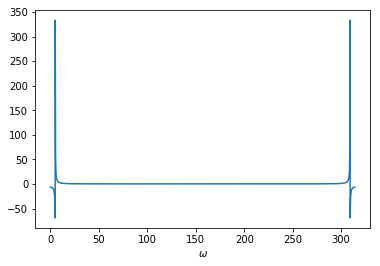

In [70]:
from scipy import fftpack
ft = fftpack.fft(r1t); plt.plot(t,ft.real); plt.xlabel(r'$\omega$'); plt.show()

Para uma série de vídeos explicando os aspectos básicos da rossonância magnética nuclear, veja [https://www.youtube.com/playlist?list=PLD14D78BC61685BD7]. Vários prêmios Nobel foram dados para pesquisas realizadas nessa área. Alguns exemplos são: [https://www.nobelprize.org/prizes/physics/1943/stern/lecture/], [https://www.nobelprize.org/prizes/physics/1944/summary/], [https://www.nobelprize.org/prizes/physics/1952/summary/], [https://www.nobelprize.org/prizes/chemistry/1991/summary/], [https://www.nobelprize.org/prizes/chemistry/2002/wuthrich/lecture/], [https://www.nobelprize.org/prizes/medicine/2003/summary/]. Não é de se estranhar se nos próximos anos outro prêmio Nobel for dado nessa área, para pesquisas sobre magnetometria quântica na escala nanométrica com vacâncias de Nitrogênio no diamente e suas aplicações em biosensores.

## MASER
Alguns sistemas, como e.g. a molécula de amônia $NH_{3}$, possuem momento de dipolo elétrico, que, no regime quântico, interage com campos elétricos segundo o Hamiltoniano (veja a Ref. 4 para mais detalhes):
\begin{equation}
H = -\vec{\mu}_{e}\cdot\vec{E}.
\end{equation}
Se experimentos do tipo Stern-Gerlach são feitos com essas partículas (com gradientes de campo elétrico), os resultados são idênticos àqueles obtidos para partículas de spin 1/2. Portanto os observáveis e estados são descritos pela "mesma matemática". Por conseguinte, se aplicamos um campo elétrico
\begin{equation}
\vec{E}(t) = E_{0}\hat{k} - E_{1}\left(\hat{i}\cos\omega t - \hat{j}\sin\omega t\right)
\end{equation}
podemos obter transições entre os estados de momento de dipolo elétrico, tal qual o caso da ressonância magnética da última seção.

No caso da amônia $\mathrm{NH_{3}}$, a frequência de Bohr $\omega_{21}$ está no intervalo de microondas:
\begin{equation}
\nu=(300\text{ MHz} - 300\text{ GHz}) \text{ ou } \lambda = (100\text{ cm} - 0,1\text{ cm}).
\end{equation}
O procedimento para obter o MASER (Microwave Amplification by Stimulated Emission of Radiation) [https://www.nobelprize.org/prizes/physics/1964/summary/] é o seguinte (veja a figura abaixo, retirada da Ref. 4). 

<img src='maser.png' width='500'>

Primeiro faz-se as molécuals passarem por um gradiente de campo elétrico na direção $z$, "selecionando" aquelas que são desviadas pra baixo naquela direção:
\begin{equation}
|?\rangle\rightarrow \boxed{SG_{z}}\begin{matrix}\rightarrow|z_{+}\rangle \rightarrow \text{descarta} \\ \rightarrow|z_{-}\rangle \rightarrow \text{seleciona}\end{matrix}.
\end{equation}
Ou seja, preparamos todas as moléculas com componente de dipolo elétrico negativa na direção $z$, i.e., as preparamos no estado $|z_{-}\rangle\equiv|2\rangle$.



Depois faz-se essas moléculas passar por uma cavidade onde aplica-se um campo oscilante no plano $xy$ (radiação de microondas), como o descrito na equação acima, na condição de ressonância $\omega=\omega_{21}$. Pode-se verificar que se a cavidade é construída de forma que as moléculas passem um tempo
\begin{equation}
t_{opt} = \frac{\pi\hbar}{2\gamma},
\end{equation}
todas as moléculas terão decaído para o estado fundamental e emitido radiação de microondas antes de sair da cavidade. Isso fará com que a radiação de microondas na cavidade seja amplificada, e isso se deve ao estímulo do campo externo.

OBS. Para verificar que o tempo é dado como acima, notamos que $k_{1}(\omega = \omega_{21}) = 1$ e portanto $Pr(1(t)) = k_{1}^{2}\sin^{2}\xi t = \sin^{2}\gamma t/\hbar$, que é máxima quando $\gamma t/\hbar=(2j+1)\pi/2$ para $j=0,1,2,3,\dots$. Para $j=0$ obtemos a expressão acima, para o menor tempo necessário para que $Pr(1(t))=1$.

OBS. Vários prêmios Nobel, para trabalhos relacionados ao LASER, estão listados em [http://laserfest.org/lasers/pioneers/nobel.cfm].

__Teoria de Einstein da radiação__ <br>
Consideremos um gás de átomos na presença de radiação eletromagnética (REM), dentro de uma cavidade, por exemplo. Consideremos dois níveis de energia $E_{m}$ e $E_{n}$ de átomos, com $E_{m}>E_{n}$. Segundo a teoria de Bohr, um átomo sujeito a uma REM poderá absorver um fóton de frequência
\begin{equation}
\nu_{mn}=\frac{E_{m}-E_{n}}{h},
\end{equation}
transitando assim do estado de menor energia $|E_{n}\rangle$ para o estado de maior energia $|E_{m}\rangle$. Se a intensidade da REM aplicada é $I(\nu)$, na frequência $\nu$, e $N_{n}$ é o número de átomos no estado $|E_{n}\rangle$, em um certo instante de tempo, a taxa temporal com que essas transições acontecem (número de transições $|E_{n}\rangle\rightarrow|E_{m}\rangle$ por segundo) pode ser escrita como
\begin{equation}
\partial_{t}N_{n} \propto N_{n}I(\nu) = B_{nm}N_{n}I(\nu).
\end{equation}

A REM também induz o átomo a fazer a transição de estados de maior energia para estados de menor energia, $|E_{m}\rangle\rightarrow|E_{n}\rangle$, em um processo denominado _emissão estimulada_. Nesse caso o átomo emite um fóton de frequência $\nu_{mn}=(E_{m}-E_{n})/h$.
Se, em um certo instante de tempo $t$, temos $N_{m}$ átomos no estado de maior energia, a taxa com que estes átomos decaem por emissão estimulada é
\begin{equation}
\partial_{t}N_{m}\propto N_{m}I(\nu) = B_{mn}N_{m}I(\nu).
\end{equation}

$B_{mn}$ e $B_{nm}$ são os chamados coeficientes $B$ de Einstein. Einstein usou conservacão do momento linear para argumentar que $B_{mn}=B_{nm}$ (veja a tradução de [Physikalische Zeitschrift18, 121 (1917)] em [Rev. Bras. Ens. Fis. 27, 93 (2005)]). Na realidade, nas condições que consideramos nestas notas de aula, e usando a suposição de Einstein de que $N_{n}(t)=N_{m}(t)$, verificamos explicitamente essa previsão e identificamos esses coeficientes:
\begin{align}
B_{nm}/N_{n}I(\nu) & = \partial_{t}N_{n} = Pr(|1\rangle\rightarrow |2\rangle) = k_{3}^{2}\sin^{2}(\xi t), \\
B_{mn}/N_{m}I(\nu) & = \partial_{t}N_{m} = Pr(|2\rangle\rightarrow |1\rangle) = k_{1}^{2}\sin^{2}(\xi t), \\
\end{align}
com
\begin{equation}
k_{1}^{2}=k_{3}^{2} = \left(1+\left(\frac{\hbar\omega_{21}}{2\gamma}\left(1-\frac{\omega}{\omega_{21}}\right)\right)^{2}\right)^{-1}.
\end{equation}

OBS. Além destes dois processos identificados, para trocas de energia entre radiação eletromagnética e matéria, existe outro efeito importante que é a _emissão espontânea_, que é explicada quantizando tanto a matéria como a radiação eletromagnética, em uma teoria denominada Óptica Quântica.

# Exercícios

1. Obtenha o comutador $[H_{t},H_{t'}]$, para o Hamiltoniano dado no início desse texto.

1. Verifique que o coeficiente $c_{2}(t)$ pode ser escrito como $c_{2}(t) = e^{-i(\omega-\omega_{21})t/2}\left(k_{3}\sin\xi t + k_{4}\cos\xi t \right)$.

1. Repita os cálculos feitos acima considerando como estado inicial $|2\rangle$. Ou seja, obtenha a constante $k_{1}$ e a probabilidade de transiçãp $Pr(|2\rangle\rightarrow|1\rangle)=Pr(1(t))$.

1. No contexto da última questão, obtenha a expressão dos tempos, $t_{\max}$, necessários para que a probabilidade de transição seja igual a um, i.e., $Pr(|2\rangle\rightarrow|1\rangle)=1$.

1. Verifique que $\langle z_{+}|\sigma_{x}|z_{+}\rangle = \langle z_{-}|\sigma_{x}|z_{-}\rangle = 0$.

1. Leia o artigo [http://www.sbfisica.org.br/rbef/pdf/cas.pdf].

1. Leia o cap. 9 do vol. 3 das Leituras de Física de Feynman [https://www.feynmanlectures.caltech.edu/III_09.html].